In [15]:
import torch
from ultralytics import YOLO
from PIL import Image, ImageDraw, ImageFont
import os
import sys
import glob
from collections import defaultdict
import matplotlib.pyplot as plt
import cv2
import numpy as np

# --- 로컬 Pororo 모듈 경로 설정 ---
# ★★★ predict2에서 검증된 'pororo_easyocr_main' 모듈 경로로 변경 ★★★
PORORO_PATH = os.path.abspath(os.path.join(os.path.dirname('.'), '..', 'pororo_easyocr_main'))
if PORORO_PATH not in sys.path:
    sys.path.append(PORORO_PATH)
    print(f"Added to sys.path: {PORORO_PATH}")

try:
    # ★★★ EasyPororoOcr 클래스를 임포트 ★★★
    from main import EasyPororoOcr
except ImportError:
    print(f"오류: '{PORORO_PATH}' 경로에서 Pororo 모듈을 찾을 수 없습니다.")
    print("customOCR 폴더와 같은 위치에 'pororo_easyocr_main' 폴더가 있는지 확인해주세요.")
    raise

print("\n필요한 모듈을 모두 로드했습니다.")


필요한 모듈을 모두 로드했습니다.


In [21]:
class YOLOv8_OCR_Predictor:
    """YOLOv8로 객체를 탐지하고, 탐지된 영역에서 OCR을 수행하는 예측기"""

    def __init__(self, model_path, font_path=None):
        # --- 1. 모델 및 OCR 엔진 로드 ---
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"YOLO 모델 가중치 파일을 찾을 수 없습니다: {model_path}")
        
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        print(f"사용 장치: {self.device.upper()}")

        print("YOLOv8 모델 로딩 중...")
        self.model = YOLO(model_path)
        self.model.to(self.device)
        
        # ★★★ EasyPororoOcr 엔진으로 초기화 ★★★
        print("EasyPororoOcr 엔진 초기화 중...")
        use_gpu = torch.cuda.is_available()
        self.ocr_reader = EasyPororoOcr(gpu=use_gpu)

        # 시각화를 위한 폰트 설정
        try:
            self.font = ImageFont.truetype(font_path or "malgun.ttf", size=15)
        except IOError:
            print("경고: 'malgun.ttf' 폰트를 찾을 수 없습니다. 기본 폰트를 사용합니다.")
            self.font = ImageFont.load_default()

    def detect_only(self, image_path, conf_threshold=0.5):
        """[1단계] 이미지에서 객체만 탐지합니다 (OCR 없음)."""
        if not os.path.exists(image_path):
            print(f"오류: 이미지 파일을 찾을 수 없습니다: {image_path}")
            return None, None

        original_image = Image.open(image_path).convert("RGB")
        results = self.model.predict(original_image, conf=conf_threshold, verbose=False)
        
        detected_objects = []
        for res in results:
            boxes = res.boxes.cpu().numpy()
            for box in boxes:
                class_id = int(box.cls[0])
                label = self.model.names[class_id]
                confidence = float(box.conf[0])
                coords = [int(c) for c in box.xyxy[0]]
                
                detected_objects.append({'label': label, 'box': coords, 'confidence': confidence})
        
        detected_objects.sort(key=lambda obj: (obj['box'][1], obj['box'][0]))
        return detected_objects, original_image

    def run_ocr_on_detections(self, original_image, detected_objects):
        """
        [2단계] 탐지된 객체 리스트에 대해 OCR을 수행합니다.
        ★★★ IoU 기반 매핑으로 정확도 향상 ★★★
        """
        # 1. 이미지 전체에 대해 OCR을 한 번만 실행
        cv_image = np.array(original_image)
        cv_image_bgr = cv2.cvtColor(cv_image, cv2.COLOR_RGB2BGR)
        final_image_for_ocr = cv_image_bgr.copy()
        
        self.ocr_reader.run_ocr(final_image_for_ocr, debug=False)
        all_ocr_results = self.ocr_reader.get_ocr_result()
        
        if not all_ocr_results:
            return []

        # 2. 각 YOLO 탐지 영역에 텍스트를 담을 리스트 초기화
        yolo_texts = [[] for _ in detected_objects]

        # 3. 각 OCR 결과를 가장 적합한(IoU가 가장 높은) YOLO 상자에 할당
        for ocr_box_poly, ocr_text in all_ocr_results:
            # OCR 다각형 좌표를 [xmin, ymin, xmax, ymax] 사각형으로 변환
            x_coords = [p[0] for p in ocr_box_poly]
            y_coords = [p[1] for p in ocr_box_poly]
            ocr_box_rect = [min(x_coords), min(y_coords), max(x_coords), max(y_coords)]
            
            best_iou = 0
            best_yolo_idx = -1
            for i, det_obj in enumerate(detected_objects):
                yolo_box = det_obj['box']
                iou = calculate_iou(yolo_box, ocr_box_rect)
                if iou > best_iou:
                    best_iou = iou
                    best_yolo_idx = i
            
            # 가장 많이 겹치는 YOLO 상자를 찾았다면 텍스트 추가
            if best_yolo_idx != -1:
                # y, x 좌표와 텍스트를 함께 저장하여 나중에 정렬
                yolo_texts[best_yolo_idx].append((ocr_box_rect[1], ocr_box_rect[0], ocr_text))

        # 4. 최종 결과 구조화
        structured_results = []
        for i, det_obj in enumerate(detected_objects):
            # 텍스트를 y, x 좌표 순으로 정렬하여 자연스러운 읽기 순서 보장
            contained_texts = sorted(yolo_texts[i])
            final_text = ' '.join([text for _, _, text in contained_texts])
            
            structured_results.append({
                'label': det_obj['label'], 'text': final_text.strip(),
                'box': det_obj['box'], 'confidence': f"{det_obj['confidence']:.2f}"
            })
            
        return structured_results

    def draw_detections(self, image, detections):
        """탐지 결과(박스 + 라벨)만 시각화합니다."""
        draw = ImageDraw.Draw(image)
        label_colors = {
            "DATE_HEADER": "#ff7f0e", "DATE": "#1f77b4", "TIME": "#d62728",
            "MERCHANT": "#2ca02c", "MEMO": "#9467bd", "AMOUNT_IN": "#8c564b",
            "AMOUNT_OUT": "#e377c2", "BALANCE": "#7f7f7f",
        }
        for det in detections:
            box, label, confidence = det['box'], det['label'], det['confidence']
            color = label_colors.get(label, "#bcbd22")
            draw.rectangle(box, outline=color, width=3)
            label_text = f"{label} ({confidence:.2f})"
            text_bbox = draw.textbbox((box[0], box[1]), label_text, font=self.font)
            label_bg_box = [box[0], box[1] - (text_bbox[3] - text_bbox[1]) - 6, box[0] + (text_bbox[2] - text_bbox[0]) + 8, box[1]]
            draw.rectangle(label_bg_box, fill=color)
            draw.text((box[0] + 4, box[1] - (text_bbox[3] - text_bbox[1]) - 4), label_text, fill="white", font=self.font)
        return image

    def draw_predictions(self, image, predictions):
        """최종 예측 결과(박스 + 라벨 + OCR 텍스트)를 시각화합니다."""
        draw = ImageDraw.Draw(image)
        label_colors = {
            "DATE_HEADER": "#ff7f0e", "DATE": "#1f77b4", "TIME": "#d62728",
            "MERCHANT": "#2ca02c", "MEMO": "#9467bd", "AMOUNT_IN": "#8c564b",
            "AMOUNT_OUT": "#e377c2", "BALANCE": "#707070FF",
        }
        for pred in predictions:
            box, label, text, confidence = pred['box'], pred['label'], pred['text'], pred['confidence']
            color = label_colors.get(label, "#bcbd22")
            draw.rectangle(box, outline=color, width=3)
            label_text = f"{label}: {text} ({confidence})"
            text_bbox = draw.textbbox((box[0], box[1]), label_text, font=self.font)
            label_bg_box = [box[0], box[1] - (text_bbox[3] - text_bbox[1]) - 6, box[0] + (text_bbox[2] - text_bbox[0]) + 8, box[1]]
            draw.rectangle(label_bg_box, fill=color)
            draw.text((box[0] + 4, box[1] - (text_bbox[3] - text_bbox[1]) - 4), label_text, fill="white", font=self.font)
        return image

print("YOLOv8_OCR_Predictor 클래스가 탐지/OCR 분리 기능으로 업데이트되었습니다.")

def calculate_iou(box_a, box_b):
    """두 경계 상자 간의 IoU(Intersection over Union)를 계산합니다."""
    # 각 상자의 (x1, y1, x2, y2) 좌표 결정
    x_a = max(box_a[0], box_b[0])
    y_a = max(box_a[1], box_b[1])
    x_b = min(box_a[2], box_b[2])
    y_b = min(box_a[3], box_b[3])

    # 교차 영역의 넓이 계산
    inter_area = max(0, x_b - x_a) * max(0, y_b - y_a)

    # 각 상자의 넓이 계산
    box_a_area = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    box_b_area = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])

    # 합집합 넓이 계산
    union_area = float(box_a_area + box_b_area - inter_area)
    
    # IoU 계산
    iou = inter_area / union_area if union_area > 0 else 0
    return iou

YOLOv8_OCR_Predictor 클래스가 탐지/OCR 분리 기능으로 업데이트되었습니다.


In [22]:
# --- 1. 설정 ---
# 학습된 YOLO 모델 가중치 파일 경로
MODEL_PATH = 'C:/code/customOCR/bank_statement_detector/yolov8m_e50_bs8/weights/best.pt'
# 테스트할 이미지가 있는 디렉토리
TEST_IMAGE_DIR = '../bank_statement_test'
TEST_IMAGE_DIR2 = '../bank_statement'
# 예측 결과 이미지를 저장할 디렉토리
OUTPUT_DIR = 'C:/code/customOCR/yolo_predictions'
# 객체 탐지를 위한 신뢰도 임계값
CONF_THRESHOLD = 0.25
# 사용할 폰트 경로 (None으로 두면 시스템 기본 폰트 또는 'malgun.ttf' 시도)
FONT_PATH = None 

# --- 2. 예측기 초기화 ---
try:
    predictor = YOLOv8_OCR_Predictor(model_path=MODEL_PATH, font_path=FONT_PATH)
except Exception as e:
    print(f"예측기 초기화 실패: {e}")
    # Stop execution if predictor fails
    raise

사용 장치: CUDA
YOLOv8 모델 로딩 중...
EasyPororoOcr 엔진 초기화 중...


In [ ]:
# --- 1단계: YOLO 영역 탐지 결과 확인 ---
test_image_files = glob.glob(os.path.join(TEST_IMAGE_DIR, '*.png')) + \
                   glob.glob(os.path.join(TEST_IMAGE_DIR, '*.jpg')) + \
                   glob.glob(os.path.join(TEST_IMAGE_DIR2, '*.png')) + \
                   glob.glob(os.path.join(TEST_IMAGE_DIR2, '*.jpg'))

if not test_image_files:
    print(f"오류: '{TEST_IMAGE_DIR}' 또는 '{TEST_IMAGE_DIR2}' 폴더에서 테스트 이미지를 찾을 수 없습니다.")
else:
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"탐지 결과 이미지를 '{OUTPUT_DIR}' 폴더에 저장합니다.")

    for image_path in test_image_files:
        detections, image = predictor.detect_only(image_path, conf_threshold=CONF_THRESHOLD)
        if detections is None:
            continue

        result_image = predictor.draw_detections(image.copy(), detections)
        
        # ★★★ 변경: 노트북에 출력하는 대신 파일로 저장 ★★★
        output_filename = "detection_" + os.path.basename(image_path)
        output_path = os.path.join(OUTPUT_DIR, output_filename)
        result_image.save(output_path)
        print(f"{os.path.basename(image_path)} -> 탐지 결과 저장 완료: {output_path}")

탐지 결과 이미지를 'C:/code/customOCR/yolo_predictions' 폴더에 저장합니다.

--- [1단계: 탐지] sc1.png ---
-> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_sc1.png

--- [1단계: 탐지] sanup1.jpg ---
-> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_sanup1.jpg

--- [1단계: 탐지] sanup2.jpg ---
-> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_sanup2.jpg

--- [1단계: 탐지] sanup3.jpg ---
-> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_sanup3.jpg

--- [1단계: 탐지] sanup4.jpg ---
-> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_sanup4.jpg

--- [1단계: 탐지] kookmin1.png ---
-> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_kookmin1.png

--- [1단계: 탐지] kookmin2.png ---
-> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_kookmin2.png

--- [1단계: 탐지] kookmin3.png ---
-> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_kookmin3.png

--- [1단계: 탐지] kookmin4.png ---
-> 탐지 결과 저장 완료: C:/code/customOCR/yolo_predictions\detection_kookmin4.png

--- [1단계: 탐지


최종 OCR 결과 이미지를 'C:/code/customOCR/yolo_predictions' 폴더에 저장하고 화면에 출력합니다.

--- [2단계: OCR+결과] sc1.png ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_sc1.png


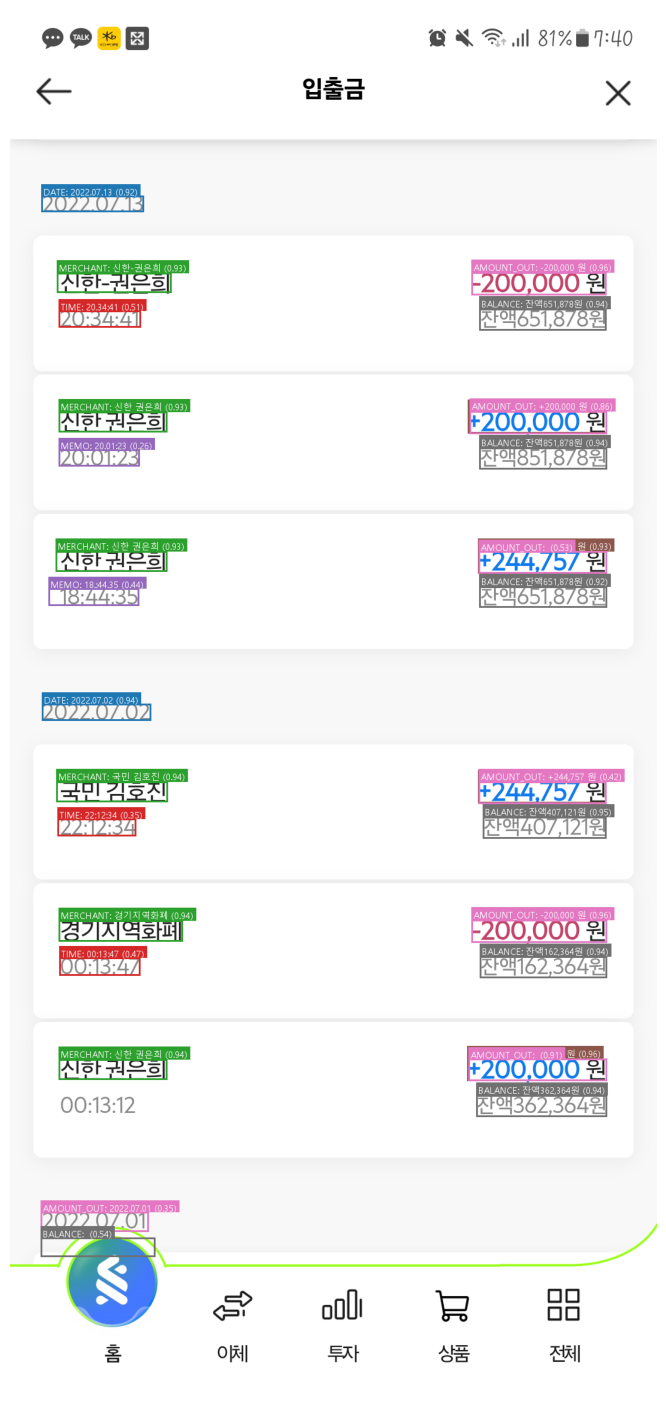

[텍스트 요약]
- AMOUNT_IN: , +244,757 원, , +200,000 원
- AMOUNT_OUT: -200,000 원, +200,000 원, , +244,757 원, -200,000 원, , 2022.07.01
- BALANCE: 잔액651,878원, 잔액851,878원, 잔액651,878원, 잔액407,121원, 잔액162,364원, 잔액362,364원, 
- DATE: 2022.07.13, 2022.07.02
- MEMO: 20.01:23, 18.:44.35
- MERCHANT: 신한-권은희, 신한 권은희, 신한 권은희, 국민 김호진, 경기지역화폐, 신한 권은희
- TIME: 20.34:41, 22:12:34, 00:13:47
--------------------------------------------------

--- [2단계: OCR+결과] sanup1.jpg ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_sanup1.jpg


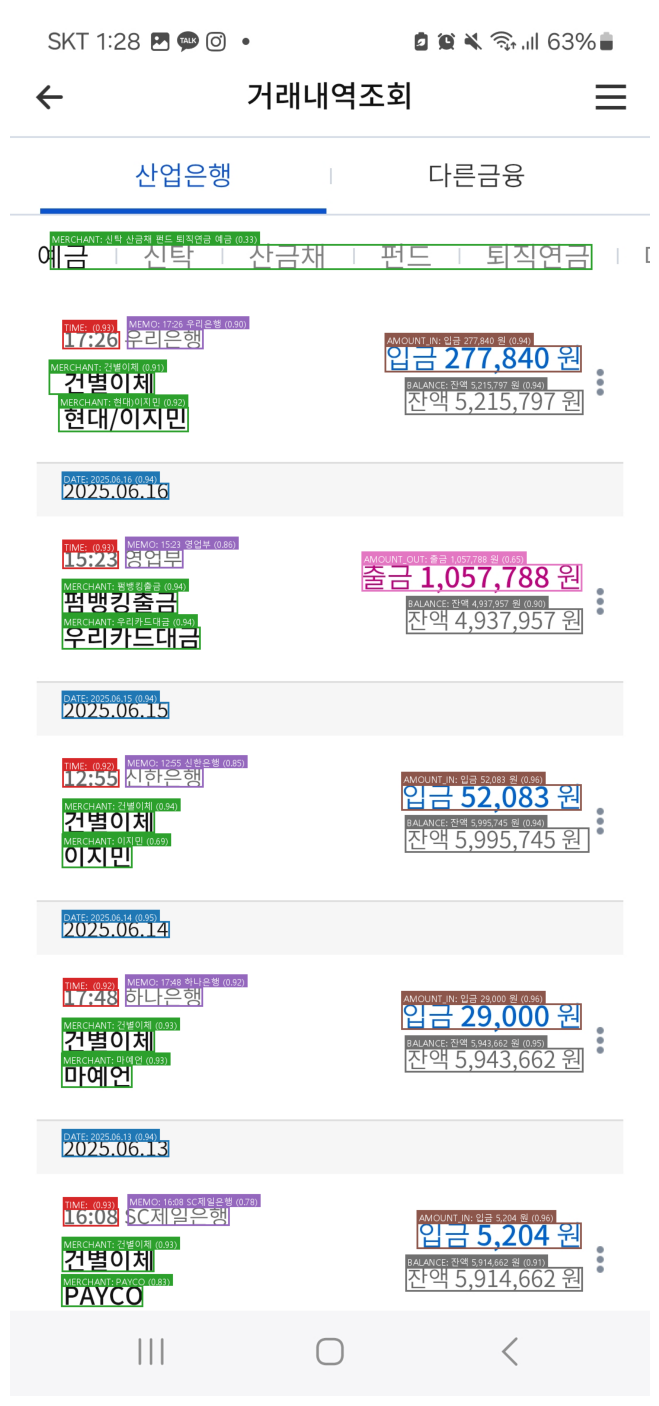

[텍스트 요약]
- AMOUNT_IN: 입금 277,840 원, 입금 52,083 원, 입금 29,000 원, 입금 5,204 원
- AMOUNT_OUT: 출금 1,057,788 원
- BALANCE: 잔액 5,215,797 원, 잔액 4,937,957 원, 잔액 5,995,745 원, 잔액 5,943,662 원, 잔액 5,914,662 원
- DATE: 2025.06.16, 2025.06.15, 2025.06.14, 2025.06.13
- MEMO: 17:26 우리은행, 15:23 영업부, 12:55 신한은행, 17:48 하나은행, 16:08 SC제일은행
- MERCHANT: 신탁 산금채 펀드 퇴직연금 예금, 건별이체, 현대)이지민, 펌뱅킹출금, 우리카드대금, 건별이체, 이지민, 건별이체, 마예언, 건별이체, PAYCO
- TIME: , , , , 
--------------------------------------------------

--- [2단계: OCR+결과] sanup2.jpg ---
-> 최종 결과 저장 완료: C:/code/customOCR/yolo_predictions\final_sanup2.jpg


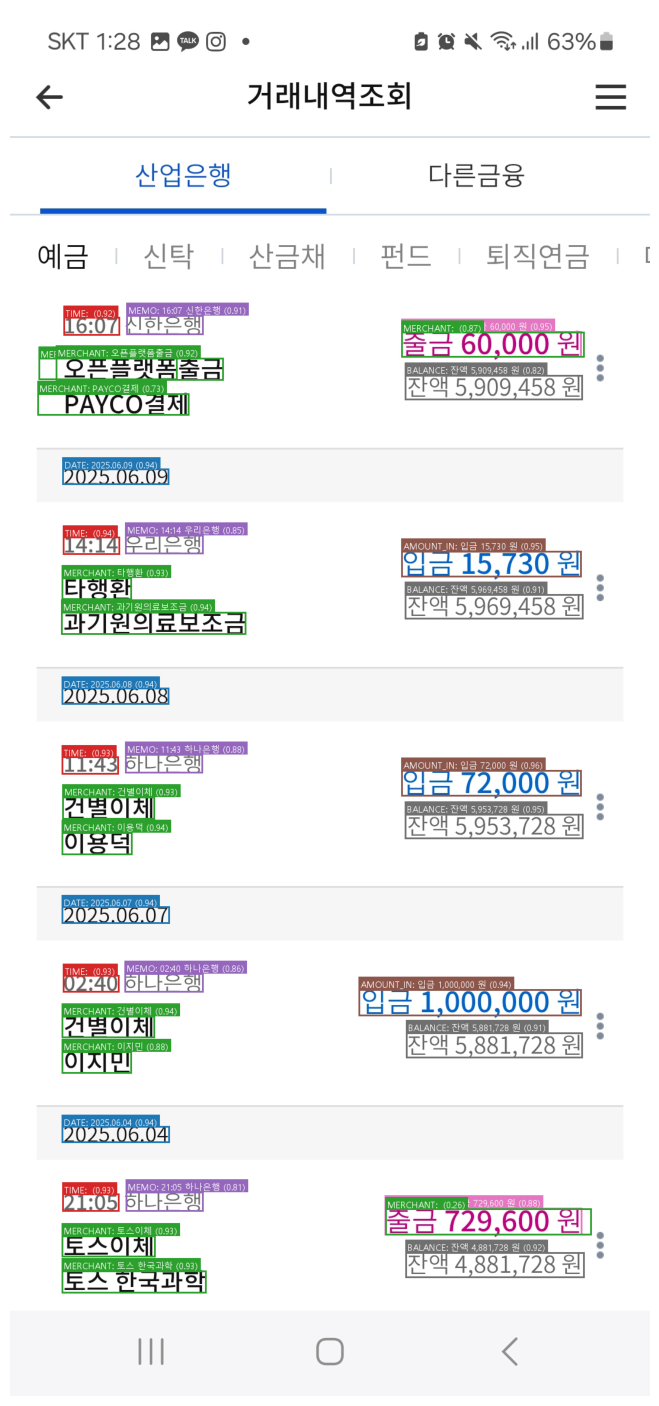

[텍스트 요약]
- AMOUNT_IN: 입금 15,730 원, 입금 72,000 원, 입금 1,000,000 원
- AMOUNT_OUT: 출금 60,000 원, 출금 729,600 원
- BALANCE: 잔액 5,909,458 원, 잔액 5,969,458 원, 잔액 5,953,728 원, 잔액 5,881,728 원, 잔액 4,881,728 원
- DATE: 2025.06.09, 2025.06.08, 2025.06.07, 2025.06.04
- MEMO: 16:07 신한은행, 14:14 우리은행, 11:43 하나은행, 02:40 하나은행, 21:05 하나은행
- MERCHANT: , , 오픈플랫폼출금, PAYCO결제, 타행환, 과기원의료보조금, 건별이체, 이용덕, 건별이체, 이지민, , 토스이체, 토스 한국과학
- TIME: , , , , 
--------------------------------------------------

--- [2단계: OCR+결과] sanup3.jpg ---


In [ ]:
# --- 2단계: OCR 적용 및 최종 결과 확인 (이미지 출력 및 파일 저장) ---
if not test_image_files:
    print(f"오류: 테스트 이미지가 없습니다. 이전 셀을 먼저 실행하세요.")
else:
    print(f"\n{'='*50}\n최종 OCR 결과 이미지를 '{OUTPUT_DIR}' 폴더에 저장하고 화면에 출력합니다.")
    for image_path in test_image_files:
        print(f"\n--- [2단계: OCR+결과] {os.path.basename(image_path)} ---")
        
        detections, image = predictor.detect_only(image_path, conf_threshold=CONF_THRESHOLD)
        if detections is None:
            continue
            
        predictions = predictor.run_ocr_on_detections(image, detections)
        result_image = predictor.draw_predictions(image.copy(), predictions)
        
        # 파일로 저장
        output_filename = "final_" + os.path.basename(image_path)
        output_path = os.path.join(OUTPUT_DIR, output_filename)
        result_image.save(output_path)
        print(f"-> 최종 결과 저장 완료: {output_path}")

        # ★★★ 변경: 노트북에 이미지 직접 출력 ★★★
        plt.figure(figsize=(10, 18))
        plt.imshow(result_image)
        plt.axis('off')
        plt.show()

        # 텍스트 요약은 계속 콘솔에 출력
        print("[텍스트 요약]")
        summary = defaultdict(list)
        for p in predictions:
            summary[p['label']].append(p['text'])
        
        for label, texts in sorted(summary.items()):
            print(f"- {label}: {', '.join(texts)}")
        print("-" * 50)